# 05. 畳み込みニューラルネット — 画像のための重み共有

## この章で分かること

- **畳み込み** が「小さなフィルタを画像全体で使い回す」操作であること
- パディング・ストライド・プーリング・チャネルの意味と shape の変化
- CNN を PyTorch で組み、MNIST / Fashion-MNIST を分類する
- 学習したフィルタ・特徴マップ・誤分類例を可視化する

全結合(MLP)で画像を扱うと、ピクセルごとに別々の重みが要り、
位置がずれただけで別物になります。畳み込みは **重み共有** と **局所性** でこれを解決します。

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from scipy.signal import convolve2d
from torch.utils.data import DataLoader, TensorDataset

from nn_textbook import datasets, plotting
from nn_textbook.training import get_device, set_seed, train_torch

set_seed(0)
# Committed outputs use the CPU; set NN_TEXTBOOK_GPU=1 to run on the GPU.
device = get_device() if os.environ.get("NN_TEXTBOOK_GPU") == "1" else torch.device("cpu")
np.set_printoptions(precision=3, suppress=True)
print("device:", device)

device: cpu


## 1. Intuition — フィルタを画像全体で使い回す

畳み込みは、小さな重みの窓(**カーネル / フィルタ**)を画像の上で滑らせ、
各位置で要素ごとの積和をとる操作です。

- 同じカーネルを全位置で使う → **重み共有**(パラメータが激減)
- 各出力は近傍だけから決まる → **局所性**(エッジなど局所特徴を捉える)
- カーネルの中身次第で「エッジ検出」「ぼかし」などになる

まず固定カーネルで、畳み込みが何をするかを目で見ます。

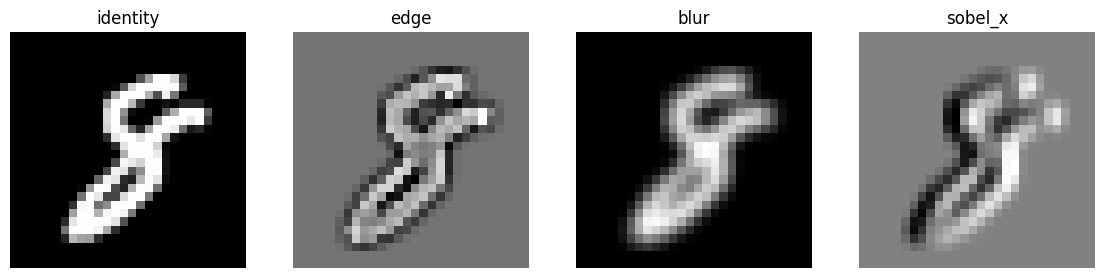

In [2]:
# Hand-designed kernels show what convolution computes (edges, blur, sharpen).
img = np.asarray(datasets.load_mnist(train=True, n=1, seed=2)[0][0]).squeeze()

kernels = {
    "identity": np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]),
    "edge": np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]),
    "blur": np.ones((3, 3)) / 9,
    "sobel_x": np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
}
fig, axes = plt.subplots(1, len(kernels), figsize=(14, 3.3))
for ax, (name, k) in zip(axes, kernels.items(), strict=True):
    ax.imshow(convolve2d(img, k, mode="same", boundary="symm"), cmap="gray")
    ax.set_title(name); ax.axis("off")
plt.show()

### インタラクティブ: 畳み込みカーネル(JupyterLab のみ)

カーネルを切り替えて出力の変化を見るデモです。静的 HTML では上の図を参照してください。

In [3]:
# Interactive (JupyterLab only): pick a kernel and see its effect.
from nn_textbook.widgets import convolution_kernel_explorer

convolution_kernel_explorer(img)

interactive(children=(Dropdown(description='name', options=('edge', 'sharpen', 'blur', 'sobel_x'), value='edge…

<function nn_textbook.widgets.convolution_kernel_explorer.<locals>.draw(name)>

## 2. Definition — 畳み込みの数式と shape

入力 $X$ にカーネル $K$($k \times k$)を畳み込むと、出力 $Y$ は:

$$
Y_{i,j} = \sum_{u=0}^{k-1}\sum_{v=0}^{k-1} K_{u,v}\, X_{i+u,\, j+v}
$$

shape を決める要素:

- **パディング $p$**: 周囲を 0 で囲む。出力が縮むのを防ぐ。
- **ストライド $s$**: 窓を何ピクセルずつ動かすか。大きいほど出力が小さい。
- 出力サイズ: $\left\lfloor \dfrac{n + 2p - k}{s} \right\rfloor + 1$
- **チャネル**: 入力 $C_\text{in}$ 枚、出力 $C_\text{out}$ 枚。カーネルは $(C_\text{out}, C_\text{in}, k, k)$。

NumPy で素朴な 2D 畳み込みを書いて、PyTorch の `conv2d` と一致することを確かめます。

In [4]:
# A from-scratch 2-D convolution, verified against torch.nn.functional.conv2d.
def conv2d_naive(x, kernel, stride=1, padding=0):
    x = np.pad(x, padding)
    k = kernel.shape[0]
    out_h = (x.shape[0] - k) // stride + 1
    out_w = (x.shape[1] - k) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = x[i * stride:i * stride + k, j * stride:j * stride + k]
            out[i, j] = np.sum(region * kernel)
    return out


k = np.array([[1.0, 0, -1], [2, 0, -2], [1, 0, -1]])   # sobel_x
ours = conv2d_naive(img, k, stride=1, padding=1)

import torch.nn.functional as F
xt = torch.tensor(img)[None, None].float()
kt = torch.tensor(k)[None, None].float()
torch_out = F.conv2d(xt, kt, stride=1, padding=1)[0, 0].numpy()

print("max abs diff (ours vs torch):", np.abs(ours - torch_out).max())
print("output shape:", ours.shape)

max abs diff (ours vs torch): 3.3155083656311035e-07
output shape: (28, 28)


In [5]:
# Padding and stride change the output size. Print the shape table.
print(f"{'padding':>8} {'stride':>7} {'output shape':>14}")
for p in [0, 1]:
    for s in [1, 2]:
        out = conv2d_naive(img, k, stride=s, padding=p)
        print(f"{p:>8} {s:>7} {str(out.shape):>14}")

 padding  stride   output shape
       0       1       (26, 26)
       0       2       (13, 13)
       1       1       (28, 28)
       1       2       (14, 14)


## 3. プーリング — 解像度を落として要約

**プーリング** は近傍をひとつの値に要約します(max pooling = 近傍の最大値)。

- 空間サイズを縮める(計算量削減)
- 小さな位置ずれに頑健になる(translation invariance)

$2 \times 2$ max pooling で画像が半分になる様子を見ます。

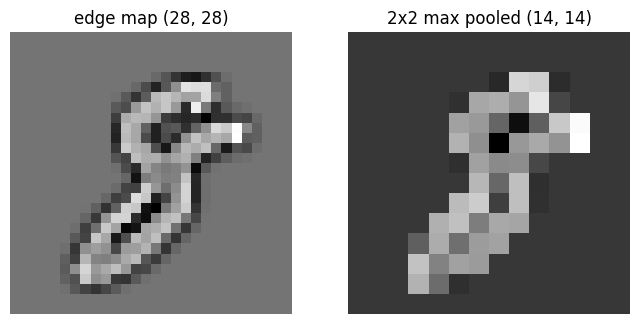

In [6]:
# Max pooling halves the spatial size and keeps the strongest responses.
edge = convolve2d(img, kernels["edge"], mode="same", boundary="symm")
pooled = F.max_pool2d(torch.tensor(edge)[None, None].float(), kernel_size=2)[0, 0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(edge, cmap="gray"); axes[0].set_title(f"edge map {edge.shape}"); axes[0].axis("off")
axes[1].imshow(pooled, cmap="gray"); axes[1].set_title(f"2x2 max pooled {pooled.shape}"); axes[1].axis("off")
plt.show()

## 4. Definition — CNN アーキテクチャ

典型的な CNN は **[畳み込み → 活性化 → プーリング] を数回 → 全結合分類器** です。

`nn_textbook.models.make_small_cnn` の構成(MNIST の 28x28 入力):

```
Conv(1→16, 3x3, pad1) → ReLU → MaxPool2  : 28x28 → 14x14
Conv(16→32, 3x3, pad1) → ReLU → MaxPool2 : 14x14 → 7x7
Flatten → Linear(32*7*7→64) → ReLU → Linear(64→10)
```

層が進むほど **空間は小さく、チャネル(特徴の種類)は多く** なるのが定石です。

In [7]:
# Build the CNN and trace the tensor shape through each stage.
from nn_textbook.models import make_small_cnn

cnn = make_small_cnn(n_classes=10, in_channels=1)
x = torch.randn(4, 1, 28, 28)   # batch 4
print(f"{'stage':<28}{'output shape'}")
h = x
for layer in cnn:
    h = layer(h)
    print(f"{layer.__class__.__name__:<28}{tuple(h.shape)}")
from nn_textbook.metrics import count_parameters
print("\ntotal parameters:", count_parameters(cnn))

stage                       output shape
Conv2d                      (4, 16, 28, 28)
ReLU                        (4, 16, 28, 28)
MaxPool2d                   (4, 16, 14, 14)
Conv2d                      (4, 32, 14, 14)
ReLU                        (4, 32, 14, 14)
MaxPool2d                   (4, 32, 7, 7)
Flatten                     (4, 1568)
Linear                      (4, 64)
ReLU                        (4, 64)
Linear                      (4, 10)

total parameters: 105866


## 5. Computation — MNIST を学習する

軽量に保つため、訓練 1 万枚・検証 2000 枚のサブセットで 4 エポックだけ学習します
(CPU でも 1 分以内)。それでも 95% 以上に届きます。

In [8]:
# Train the CNN on an MNIST subset (kept small to run fast on CPU).
def mnist_loaders(n_train=10000, n_val=2000, batch=128):
    tr = datasets.load_mnist(train=True, n=n_train, seed=0)
    va = datasets.load_mnist(train=False, n=n_val, seed=0)
    Xtr = torch.stack([im for im, _ in tr]); ytr = torch.tensor([y for _, y in tr])
    Xva = torch.stack([im for im, _ in va]); yva = torch.tensor([y for _, y in va])
    return (DataLoader(TensorDataset(Xtr, ytr), batch_size=batch, shuffle=True),
            DataLoader(TensorDataset(Xva, yva), batch_size=256), Xva, yva)


tr_loader, va_loader, Xva, yva = mnist_loaders()
set_seed(0)
cnn = make_small_cnn()
opt = torch.optim.Adam(cnn.parameters(), lr=1e-3)
hist = train_torch(cnn, tr_loader, loss_fn=nn.CrossEntropyLoss(), optimizer=opt,
                   epochs=4, device=device, val_loader=va_loader)
print("val accuracy per epoch:", [round(a, 3) for a in hist["val_acc"]])

val accuracy per epoch: [0.881, 0.936, 0.952, 0.959]


## 6. Visualization — 学習したフィルタと特徴マップ

第 1 畳み込み層が学習した 16 個のフィルタと、入力画像に対する特徴マップ(各フィルタの応答)を見ます。
フィルタはエッジや向きの検出器に育ち、特徴マップはどこが反応したかを示します。

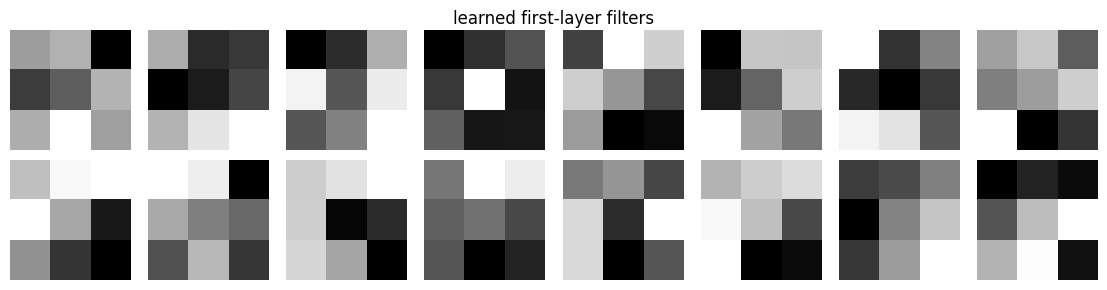

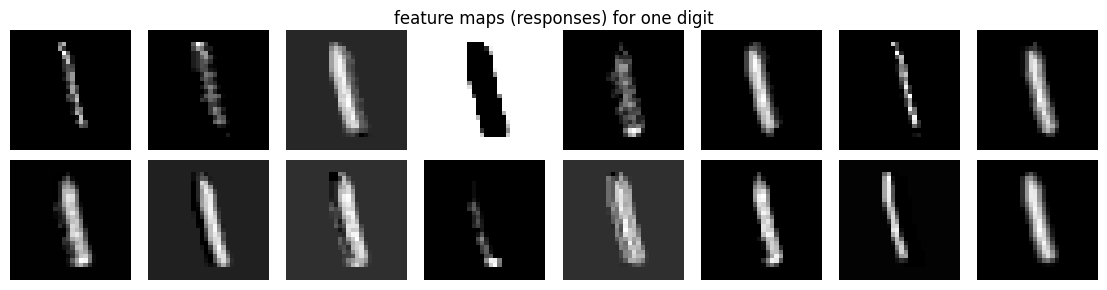

In [9]:
# Learned first-layer filters and the feature maps they produce.
conv1 = cnn[0]
filters = conv1.weight.detach().cpu().numpy()    # (16, 1, 3, 3)
plotting.plot_image_grid([filters[i, 0] for i in range(16)], ncols=8)
plt.suptitle("learned first-layer filters", y=1.02)
plt.show()

sample = Xva[0:1].to(device)
with torch.no_grad():
    fmap = torch.relu(conv1(sample))[0].cpu().numpy()   # (16, 28, 28)
plotting.plot_image_grid([fmap[i] for i in range(16)], ncols=8)
plt.suptitle("feature maps (responses) for one digit", y=1.02)
plt.show()

## 7. Failure Mode — 誤分類を見る

モデルがどこで間違えるかを見ると、改善のヒントになります。
誤分類された画像を、予測ラベルと正解ラベル付きで表示します。

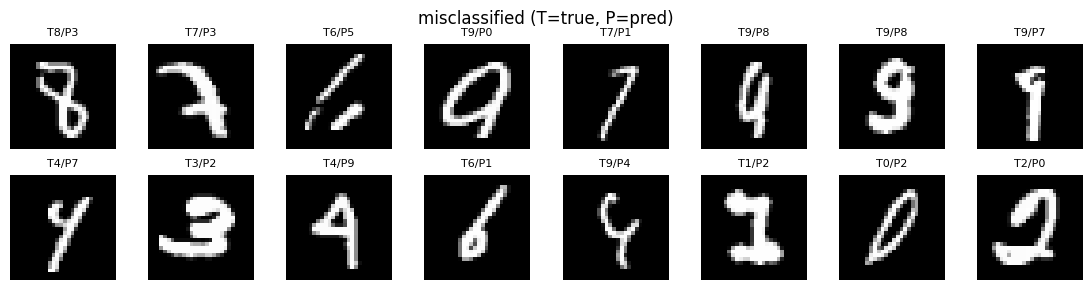

validation accuracy: 0.959  (16 of first errors shown)


In [10]:
# Inspect misclassified examples: true vs predicted labels.
cnn.eval()
with torch.no_grad():
    preds = cnn(Xva.to(device)).argmax(1).cpu()
wrong = (preds != yva).nonzero().ravel()[:16]
plotting.plot_image_grid(
    [Xva[i] for i in wrong],
    titles=[f"T{yva[i].item()}/P{preds[i].item()}" for i in wrong],
    ncols=8,
)
plt.suptitle("misclassified (T=true, P=pred)", y=1.02)
plt.show()
print(f"validation accuracy: {(preds == yva).float().mean():.3f}  ({len(wrong)} of first errors shown)")

誤分類の多くは、人間でも紛らわしい崩れた字です。

### Fashion-MNIST で混同行列を見る

クラスが「服の種類」になると、混同の構造はもっとはっきりします。
同じ CNN を Fashion-MNIST で学習し、**混同行列**(どのクラスをどのクラスと間違えるか)を見ます。

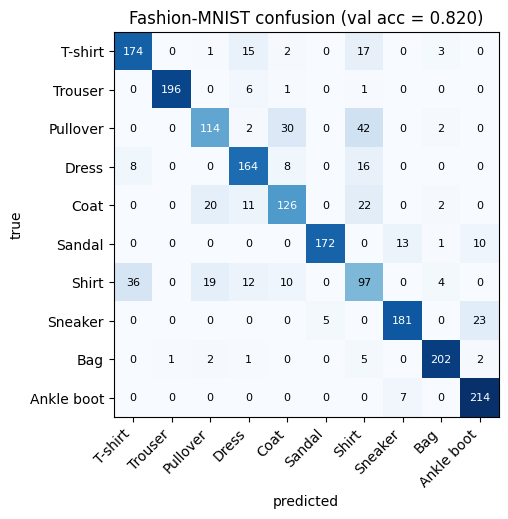

   Pullover -> Shirt    : 42 times
      Shirt -> T-shirt  : 36 times
   Pullover -> Coat     : 30 times


In [11]:
# Same CNN on Fashion-MNIST: the confusion matrix shows WHICH classes get mixed up.
from nn_textbook.metrics import confusion_matrix

def fashion_loaders(n_train=8000, n_val=2000, batch=128):
    tr = datasets.load_fashion_mnist(train=True, n=n_train, seed=0)
    va = datasets.load_fashion_mnist(train=False, n=n_val, seed=0)
    Xtr = torch.stack([im for im, _ in tr]); ytr = torch.tensor([y for _, y in tr])
    Xva = torch.stack([im for im, _ in va]); yva = torch.tensor([y for _, y in va])
    return (DataLoader(TensorDataset(Xtr, ytr), batch_size=batch, shuffle=True),
            DataLoader(TensorDataset(Xva, yva), batch_size=256), Xva, yva)


ftr_loader, fva_loader, fXva, fyva = fashion_loaders()
set_seed(0)
fcnn = make_small_cnn()
opt = torch.optim.Adam(fcnn.parameters(), lr=1e-3)
fhist = train_torch(fcnn, ftr_loader, loss_fn=nn.CrossEntropyLoss(), optimizer=opt,
                    epochs=4, device=device, val_loader=fva_loader)

fcnn.eval()
with torch.no_grad():
    fpreds = fcnn(fXva.to(device)).argmax(1).cpu()
cm = confusion_matrix(fyva.numpy(), fpreds.numpy(), n_classes=10)
plotting.plot_confusion_matrix(cm, class_names=datasets.FASHION_CLASSES)
plt.title(f"Fashion-MNIST confusion (val acc = {fhist['val_acc'][-1]:.3f})")
plt.show()

# The most confused class pairs, off the diagonal.
off = cm.copy(); np.fill_diagonal(off, 0)
flat = np.argsort(off.ravel())[::-1][:3]
for k in flat:
    i, j = divmod(k, 10)
    print(f"  {datasets.FASHION_CLASSES[i]:>9} -> {datasets.FASHION_CLASSES[j]:<9}: {off[i, j]} times")

予想どおり、**シャツ / Tシャツ / プルオーバー / コート** のような形の似た衣類同士で
混同が集中します。混同行列は「モデルが何を区別できていないか」を教えてくれる、
改善の出発点です(データ追加・拡張の優先順位づけに直結)。

## 8. CNN vs MLP — 重み共有の効き目

同程度のパラメータ数で、CNN と全結合 MLP を MNIST で比べます。
CNN は局所性と重み共有のおかげで、少ないパラメータで高い精度を出します。

In [12]:
# Same task, CNN vs MLP: CNN reaches higher accuracy per parameter.
from nn_textbook.metrics import count_parameters

set_seed(0)
mlp = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
opt = torch.optim.Adam(mlp.parameters(), lr=1e-3)
hist_mlp = train_torch(mlp, tr_loader, loss_fn=nn.CrossEntropyLoss(), optimizer=opt,
                       epochs=4, device=device, val_loader=va_loader)

print(f"CNN : params={count_parameters(cnn):>7}  val_acc={hist['val_acc'][-1]:.3f}")
print(f"MLP : params={count_parameters(mlp):>7}  val_acc={hist_mlp['val_acc'][-1]:.3f}")

CNN : params= 105866  val_acc=0.959
MLP : params= 101770  val_acc=0.925


## 9. Application — CNN の広がり

畳み込みの「局所パターンを重み共有で検出する」発想は画像以外にも広がりました。

- 画像分類・物体検出・セグメンテーション(医療画像、自動運転)
- 音声・時系列(1D 畳み込み)
- 近年は Vision Transformer(07 章の注意)が大規模データで CNN を上回る場面も多いが、
  データ効率や局所性の観点で CNN は今も現役

「重み共有 + 局所性」という帰納バイアスが、画像で CNN を強くしています。

## 10. まとめ

- 畳み込み = **小さなカーネルの重み共有**。パラメータ数は入力解像度に依存しない。
- 出力サイズは $\lfloor (n + 2p - k)/s \rfloor + 1$。プーリングで空間を縮め、位置ずれに頑健になる。
- 層が進むほど **空間は小さく、チャネルは多く**。フィルタはエッジ検出器などに育つ。
- 同程度のパラメータ数なら **CNN > MLP**(局所性 + 重み共有という帰納バイアスの勝利)。
- 誤分類例と **混同行列** が改善の出発点(どのクラス対が区別できていないか)。

## 11. Exercises

1. `conv2d_naive` でストライド 2・パディング 0 の出力サイズを式と照合せよ。
2. Fashion-MNIST の混同行列(§7)で 2 番目・3 番目に混同が多いクラス対について、
   実際の誤分類画像を表示し、人間にも紛らわしいか確認せよ。
3. 第 1 層のフィルタ数を 8 / 16 / 32 と変え、精度とパラメータ数のトレードオフを調べよ。
4. プーリングを max から average に変えると精度・特徴マップがどう変わるか観察せよ。
5. カーネルサイズを 3 から 5 にし、受容野と出力サイズ・精度の変化を述べよ。
6. (発展)2 層目の特徴マップも可視化し、1 層目より抽象的になっているか観察せよ。

## 12. Advanced Notes

**畳み込みと相互相関。** 機械学習で「convolution」と呼ぶ演算は、数学的には
カーネルを反転しない **相互相関 (cross-correlation)** です。学習でカーネルが自由なので
反転の有無は重みの定義に吸収され、実用上は無視できます。

**受容野 (receptive field)。** 出力 1 画素が「見ている」入力領域。層を重ね・プーリングするほど
広がり、深い層ほど大域的な特徴を捉えます。受容野の設計は CNN アーキテクチャの要点。

**パラメータ共有の数え方。** $C_\text{in}{=}1, C_\text{out}{=}16, k{=}3$ の畳み込みは
$16 \times 1 \times 3 \times 3 + 16 = 160$ パラメータで、入力解像度に依存しません。
同じ仕事を全結合でやれば入力サイズ × 出力サイズの巨大な重みが要ります。これが CNN の効率の源。

**現代 CNN の部品。** 1x1 畳み込み(チャネル混合)、深さ方向分離畳み込み(MobileNet)、
バッチ正規化(04 章)、残差接続(04 章の ResNet)などを組み合わせて深く・効率的にします。
全結合分類器の代わりに global average pooling を使う設計も一般的です。